# DeepFish segmentation evaluation

Two evaluation groups on the DeepFish test split:

## Group A — Standalone segmenters (5-way)

| Slot | Model | Notes |
|---|---|---|
| `yolo` | YOLO (ours) | DeepFish-trained YOLO seg from `deepfish_yolo_segmentation.ipynb` |
| `fsc` | Fishial-FSC | fishsense-core's Rust/ONNX port of upstream MaskRCNN |
| `fu` | Fishial-Upstream-MaskRCNN | upstream Python interpreter + TorchScript MaskRCNN — the legacy model |
| `ff` | Fishial-Upstream-FPN | upstream's *new* FPN+ResNet18 binary semantic segmenter |
| `sam3` | SAM 3.1 (text="fish") | Meta's [SAM 3](https://github.com/facebookresearch/sam3) foundation segmenter, open-vocabulary text prompt |

## Group B — Detect-then-segment pipelines (5-way)

All pipelines use upstream's **YOLOv26** as the detector front-end.

| Slot | Pipeline | Per-box strategy |
|---|---|---|
| `pyolo` | YOLO26 → YOLO ours | Crop + segment |
| `pfsc`  | YOLO26 → Fishial-FSC | Crop + segment |
| `pfu`   | YOLO26 → Fishial-Upstream-MaskRCNN | Crop + segment |
| `pff`   | YOLO26 → Fishial-Upstream-FPN | Crop + segment |
| `psam3` | YOLO26 → SAM 3.1 | Native bbox prompt (no cropping) |

## What each comparison isolates

- **`yolo` vs `fu`/`ff`/`sam3`** — in-domain training (DeepFish YOLO) vs zero-shot Fishial/foundation models.
- **`fsc` vs `fu`** — port drift only (same MaskRCNN weights).
- **`fu` vs `ff`** — old vs new upstream Fishial segmenter.
- **`sam3` vs everyone** — open-vocab foundation model with text="fish" prompt vs domain-trained segmenters.
- **Group B vs Group A within a slot** — does YOLO26 cropping/prompting help that segmenter?

## Setup

- **`fishsense-core`** — Rust toolchain + `uv sync --reinstall-package fishsense-core --config-setting 'build-args=--features cuda'` for the v2.1.0 CUDA build.
- **Upstream Fishial models** — auto-downloaded into `.upstream_fishial/` on first run (~250MB).
- **SAM 3.1** — place `sam3.1_multiplex.pt` (gated download from [`facebook/sam3.1`](https://huggingface.co/facebook/sam3.1)) at the repo root. The `sam3` package itself is auto-installed via `uv sync` (with `tool.uv.override-dependencies = ["numpy>=2.3.5"]` working around its stale `numpy<2` pin).

**Hardware note**: SAM 3.1 needs ~4 GB of GPU memory in bfloat16. With the other models loaded, full-eval VRAM peak is ~5–6 GB. A 6 GB card (RTX 3060) will be tight; **8 GB+ recommended** for comfortable headroom. If you OOM, comment out the SAM 3 block in the loader cell to fall back to the 4-way comparison without it.

Each loader is wrapped in try/except — unavailable models are skipped cleanly downstream.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO

In [2]:
DATA_ROOT = Path("./data/DeepFish/Segmentation")
TEST_CSV = DATA_ROOT / "test.csv"
YOLO_WEIGHTS = Path("./runs/segment/train/weights/best.pt")

test_df = pd.read_csv(TEST_CSV)
len(test_df), YOLO_WEIGHTS.exists()

(186, True)

In [3]:
def resolve_pair(row_id: str) -> tuple[Path, Path]:
    # row_id is e.g. "valid/9908_Epinephelus_f000140" or "empty/7490_NF3_f000010"
    return (
        DATA_ROOT / "images" / f"{row_id}.jpg",
        DATA_ROOT / "masks" / f"{row_id}.png",
    )

samples = []
for _, row in test_df.iterrows():
    image_path, mask_path = resolve_pair(row["ID"])
    if image_path.exists() and mask_path.exists():
        split = "valid" if row["labels"] == 1 else "empty"
        samples.append({"id": image_path.stem, "split": split, "image": image_path, "mask": mask_path})

len(samples), sum(s["split"] == "valid" for s in samples), sum(s["split"] == "empty" for s in samples)

(186, 96, 90)

In [4]:
def load_gt_mask(mask_path: Path) -> np.ndarray:
    m = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if m.ndim == 3:
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)
    return (m >= 127).astype(np.uint8)

In [5]:
yolo_model = YOLO(str(YOLO_WEIGHTS))

def yolo_predict_mask(image_bgr: np.ndarray, conf: float = 0.25) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    union = np.zeros((h, w), dtype=np.uint8)
    res = yolo_model.predict(image_bgr, verbose=False, imgsz=640, conf=conf)[0]
    if res.masks is None:
        return union
    # masks.xy is a list of (P, 2) float arrays in original-image pixel coords.
    for poly in res.masks.xy:
        if poly is None or len(poly) < 3:
            continue
        cv2.fillPoly(union, [poly.astype(np.int32)], 1)
    return union

In [ ]:
import sys
import urllib.request
import zipfile
import logging
import torch

UPSTREAM_DIR = Path(".upstream_fishial")
UPSTREAM_DIR.mkdir(exist_ok=True)

# (1) Fishial-FSC — fishsense-core's Rust/ONNX port of upstream MaskRCNN.
try:
    from fishsense_core.fish import FishSegmentation as _FSC
    fsc_seg = _FSC()
    fsc_seg.load_model()
    HAS_FSC = True
except Exception as e:
    print(f"fishsense-core unavailable: {e}")
    fsc_seg = None
    HAS_FSC = False

def fsc_predict_mask(image_bgr: np.ndarray) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    if not HAS_FSC:
        return np.zeros((h, w), dtype=np.uint8)
    try:
        out = fsc_seg.inference(image_bgr)
    except ValueError:
        return np.zeros((h, w), dtype=np.uint8)
    return (out > 0).astype(np.uint8)

# (2) Fishial-Upstream-MaskRCNN — upstream's Python interpreter + TorchScript MaskRCNN.
INTERP_PATH = UPSTREAM_DIR / "interpreter_segm.py"
MASKRCNN_PATH = UPSTREAM_DIR / "segmentation_21_08_2023.ts"
if not INTERP_PATH.exists():
    print("Downloading upstream interpreter_segm.py...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fishial/fish-identification/main/module/segmentation_package/interpreter_segm.py",
        INTERP_PATH,
    )
if not MASKRCNN_PATH.exists():
    print("Downloading upstream MaskRCNN TorchScript (~200MB, one-time)...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/fishial-ml-resources/segmentation_21_08_2023.ts",
        MASKRCNN_PATH,
    )
try:
    import shapely  # noqa: F401
except ImportError as e:
    raise RuntimeError(
        "shapely is required by the upstream Fishial interpreter. "
        "Run `uv sync` (or `uv add shapely`) and restart the notebook kernel."
    ) from e
if str(UPSTREAM_DIR) not in sys.path:
    sys.path.insert(0, str(UPSTREAM_DIR))
logging.getLogger().disabled = True
try:
    from interpreter_segm import SegmentationInference as _Upstream
    fu_seg = _Upstream(str(MASKRCNN_PATH))
    HAS_FU = True
except Exception as e:
    print(f"Fishial upstream MaskRCNN unavailable: {e}")
    fu_seg = None
    HAS_FU = False

def _polys_to_union(polys: list, h: int, w: int) -> np.ndarray:
    union = np.zeros((h, w), dtype=np.uint8)
    for p in polys:
        if not p: continue
        n = len(p) // 2
        pts = np.array([[p[f"x{i+1}"], p[f"y{i+1}"]] for i in range(n)], dtype=np.int32)
        if len(pts) < 3: continue
        cv2.fillPoly(union, [pts], 1)
    return union

def fu_predict_mask(image_bgr: np.ndarray) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    if not HAS_FU:
        return np.zeros((h, w), dtype=np.uint8)
    try:
        polys, _ = fu_seg.inference(image_bgr)
    except Exception:
        return np.zeros((h, w), dtype=np.uint8)
    return _polys_to_union(polys, h, w)

# (3) Fishial-Upstream-FPN.
FPN_ZIP = UPSTREAM_DIR / "segmentator_fpn_res18_416_1.zip"
FPN_DIR = UPSTREAM_DIR / "segmentator_fpn_res18_416_1"
FPN_SIZE = 416
FPN_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
FPN_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

if not FPN_DIR.exists():
    if not FPN_ZIP.exists():
        print("Downloading upstream FPN+ResNet18 segmenter (~50MB)...")
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/fishial-ml-resources/segmentator_fpn_res18_416_1.zip",
            FPN_ZIP,
        )
    with zipfile.ZipFile(FPN_ZIP) as z:
        z.extractall(FPN_DIR)

fpn_weights = next(
    (p for p in FPN_DIR.rglob("*") if p.suffix in {".ts", ".torchscript", ".pt"}),
    None,
)
try:
    if fpn_weights is None:
        raise FileNotFoundError(f"No model file under {FPN_DIR}")
    ff_model = torch.jit.load(str(fpn_weights), map_location="cpu")
    ff_model.eval()
    HAS_FF = True
except Exception as e:
    print(f"Fishial-Upstream-FPN unavailable: {e}")
    ff_model = None
    HAS_FF = False

@torch.no_grad()
def ff_predict_mask(image_bgr: np.ndarray) -> np.ndarray:
    h, w = image_bgr.shape[:2]
    if not HAS_FF or h == 0 or w == 0:
        return np.zeros((h, w), dtype=np.uint8)
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (FPN_SIZE, FPN_SIZE), interpolation=cv2.INTER_LINEAR)
    arr = resized.astype(np.float32) / 255.0
    arr = (arr - FPN_MEAN) / FPN_STD
    tensor = torch.from_numpy(arr.transpose(2, 0, 1)).unsqueeze(0).float()
    try:
        logits = ff_model(tensor)
    except Exception:
        return np.zeros((h, w), dtype=np.uint8)
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    prob = torch.sigmoid(logits).squeeze().cpu().numpy()
    if prob.ndim == 3:
        prob = prob[0]
    mask_small = (prob > 0.5).astype(np.uint8)
    return cv2.resize(mask_small, (w, h), interpolation=cv2.INTER_NEAREST)

# (4) Fishial-YOLO26 — upstream's YOLOv26 fish *detector*.
YOLO26_ZIP = UPSTREAM_DIR / "detector_v26_n3.zip"
YOLO26_DIR = UPSTREAM_DIR / "detector_v26_n3"

if not YOLO26_DIR.exists():
    if not YOLO26_ZIP.exists():
        print("Downloading upstream YOLOv26 detector (~10MB)...")
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/fishial-ml-resources/detector_v26_n3.zip",
            YOLO26_ZIP,
        )
    with zipfile.ZipFile(YOLO26_ZIP) as z:
        z.extractall(YOLO26_DIR)

yolo26_weights = next(
    (p for p in YOLO26_DIR.rglob("*") if p.suffix in {".torchscript", ".pt"}),
    None,
)
try:
    if yolo26_weights is None:
        raise FileNotFoundError(f"No .torchscript or .pt under {YOLO26_DIR}")
    fy_model = YOLO(str(yolo26_weights))
    HAS_FY = True
except Exception as e:
    print(f"Fishial-YOLO26 unavailable: {e}")
    fy_model = None
    HAS_FY = False

def fy_boxes(image_bgr: np.ndarray, conf: float = 0.25) -> list[tuple[int, int, int, int, float]]:
    """Returns [(x1, y1, x2, y2, score), ...] from YOLO26."""
    h, w = image_bgr.shape[:2]
    if not HAS_FY:
        return []
    res = fy_model.predict(image_bgr, verbose=False, imgsz=640, conf=conf)[0]
    if res.boxes is None:
        return []
    out = []
    for box, score in zip(res.boxes.xyxy.cpu().numpy(), res.boxes.conf.cpu().numpy()):
        x1, y1, x2, y2 = box.astype(int)
        x1 = max(0, x1); y1 = max(0, y1); x2 = min(w, x2); y2 = min(h, y2)
        if x2 > x1 and y2 > y1:
            out.append((int(x1), int(y1), int(x2), int(y2), float(score)))
    return out

# (5) SAM 3.1 — Meta's promptable foundation segmenter, standalone `sam3` package.
# Open-vocab text prompts (Group A: prompt="fish") AND geometric box prompts
# (Group B: feed YOLO26 boxes directly). Requires ~4 GB GPU memory in bf16.
# The standalone `sam3` package's setup.py pins numpy<2 but works fine on
# numpy 2.x at runtime; pyproject.toml has `tool.uv.override-dependencies`
# to allow the resolver to coexist with fishsense-core (numpy>=2.3).
SAM3_WEIGHTS = Path("sam3.1_multiplex.pt")
from PIL import Image as _PILImage

try:
    import sam3  # noqa: F401  ensure import-time setup runs
    from sam3.model_builder import build_sam3_image_model
    from sam3.model.sam3_image_processor import Sam3Processor

    if not SAM3_WEIGHTS.exists():
        raise FileNotFoundError(
            f"{SAM3_WEIGHTS} not found at repo root. "
            "Download from https://huggingface.co/facebook/sam3.1 (gated)."
        )

    # tf32 on Ampere+ is ~free perf; sam3's own example notebook enables it.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

    sam3_model = build_sam3_image_model(checkpoint_path=str(SAM3_WEIGHTS))
    sam3_model = sam3_model.eval()
    if torch.cuda.is_available():
        sam3_model = sam3_model.to("cuda")
    sam3_processor = Sam3Processor(sam3_model)
    HAS_SAM3 = True
except Exception as e:
    print(f"SAM 3 unavailable: {e}")
    sam3_model = None
    sam3_processor = None
    HAS_SAM3 = False

def _bgr_to_pil_rgb(image_bgr: np.ndarray):
    return _PILImage.fromarray(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))

def _extract_sam3_masks_scores(out, h: int, w: int):
    """Pull (masks, scores) lists from SAM 3 processor output, resize masks to (h, w)."""
    masks = out.get("masks", None) if isinstance(out, dict) else None
    scores = out.get("scores", None) if isinstance(out, dict) else None
    if masks is None or len(masks) == 0:
        return [], []
    masks_np = masks.detach().cpu().float().numpy() if hasattr(masks, "cpu") else np.asarray(masks)
    if scores is not None and hasattr(scores, "cpu"):
        scores_np = scores.detach().cpu().float().numpy()
    elif scores is None:
        scores_np = np.ones(len(masks_np), dtype=np.float32)
    else:
        scores_np = np.asarray(scores)
    out_masks, out_scores = [], []
    for m, s in zip(masks_np, scores_np):
        if m.ndim == 3: m = m[0]
        if m.shape != (h, w):
            m = cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST)
        out_masks.append((m > 0).astype(np.uint8))
        out_scores.append(float(s))
    return out_masks, out_scores

def _sam3_text_prompt(image_bgr: np.ndarray, prompt: str = "fish"):
    """Run SAM 3 with a text prompt under the bf16 autocast + inference_mode contexts
    that sam3's own example notebook uses globally. Scoped here so other torch ops
    (yolo, ff) aren't affected."""
    with torch.inference_mode(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
        state = sam3_processor.set_image(_bgr_to_pil_rgb(image_bgr))
        return sam3_processor.set_text_prompt(prompt=prompt, state=state)

def _sam3_box_prompt(image_bgr: np.ndarray, box: tuple):
    """Box prompt = (x1, y1, x2, y2) pixel coords. Returns processor output dict."""
    h, w = image_bgr.shape[:2]
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2) / w
    cy = ((y1 + y2) / 2) / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h
    with torch.inference_mode(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
        state = sam3_processor.set_image(_bgr_to_pil_rgb(image_bgr))
        return sam3_processor.add_geometric_prompt(box=[cx, cy, bw, bh], label=True, state=state)

def sam3_predict_mask(image_bgr: np.ndarray, conf: float = 0.3) -> np.ndarray:
    """Group A: text-prompt 'fish' on full image. Returns binary union of detected fish."""
    h, w = image_bgr.shape[:2]
    if not HAS_SAM3 or h == 0 or w == 0:
        return np.zeros((h, w), dtype=np.uint8)
    try:
        out = _sam3_text_prompt(image_bgr, "fish")
    except Exception as e:
        print(f"sam3 text-prompt failed: {e}")
        return np.zeros((h, w), dtype=np.uint8)
    masks, scores = _extract_sam3_masks_scores(out, h, w)
    union = np.zeros((h, w), dtype=np.uint8)
    for m, s in zip(masks, scores):
        if s >= conf:
            union |= m
    return union

def sam3_predict_full_mask_for_box(image_bgr: np.ndarray, box: tuple) -> np.ndarray:
    """Group B: feed a YOLO26 box as a SAM 3 geometric prompt. Returns full-image binary mask."""
    h, w = image_bgr.shape[:2]
    if not HAS_SAM3:
        return np.zeros((h, w), dtype=np.uint8)
    try:
        out = _sam3_box_prompt(image_bgr, box)
    except Exception:
        return np.zeros((h, w), dtype=np.uint8)
    masks, scores = _extract_sam3_masks_scores(out, h, w)
    if not masks:
        return np.zeros((h, w), dtype=np.uint8)
    return masks[0]  # take the highest-score mask for this box

print(
    f"YOLO (ours): yes  "
    f"Fishial-FSC: {'yes' if HAS_FSC else 'no'}  "
    f"Fishial-Upstream-MaskRCNN: {'yes' if HAS_FU else 'no'}  "
    f"Fishial-Upstream-FPN: {'yes' if HAS_FF else 'no'}  "
    f"Fishial-YOLO26: {'yes' if HAS_FY else 'no'}  "
    f"SAM 3 (text+box): {'yes' if HAS_SAM3 else 'no'}"
)


In [7]:
import time

# Probe whether fishsense-core is using CUDA. The Rust crate registers the
# CUDA execution provider unconditionally when built with --features cuda,
# but ORT silently falls back to CPU if the CUDA libs can't be loaded at
# runtime. The cheap way to tell which one happened: time a single inference.
# CPU MaskRCNN at 1080p ~= 4–5s; CUDA on a recent NVIDIA GPU ~= 50–500ms.
def _probe_fsc_cuda():
    if not HAS_FSC:
        return None
    sample_img = cv2.imread(str(samples[0]["image"]))
    if sample_img is None:
        return None
    fsc_seg.inference(sample_img)  # warm-up (kernel compile, weights -> GPU)
    N = 3
    t0 = time.perf_counter()
    for _ in range(N):
        fsc_seg.inference(sample_img)
    return (time.perf_counter() - t0) / N

import torch
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
fsc_ms = _probe_fsc_cuda()
if fsc_ms is not None:
    label = "CUDA" if fsc_ms < 1.0 else "CPU (slow — verify build used --features cuda)"
    print(f"Fishial-FSC inference (warm): {fsc_ms*1000:.0f} ms/image  ({label})")


torch.cuda.is_available(): True
Fishial-FSC inference (warm): 200 ms/image  (CUDA)


In [8]:
def binary_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return 1.0 if union == 0 else float(inter / union)

def binary_dice(pred: np.ndarray, gt: np.ndarray) -> float:
    s = pred.sum() + gt.sum()
    return 1.0 if s == 0 else float(2.0 * np.logical_and(pred, gt).sum() / s)

def pixel_pr(pred: np.ndarray, gt: np.ndarray) -> tuple[float, float]:
    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, np.logical_not(gt)).sum())
    fn = int(np.logical_and(np.logical_not(pred), gt).sum())
    precision = tp / (tp + fp) if (tp + fp) else float(gt.sum() == 0)
    recall = tp / (tp + fn) if (tp + fn) else 1.0
    return precision, recall

In [ ]:
# --- Group A: standalone segmenters ---
records = []
for sample in tqdm(samples):
    image_bgr = cv2.imread(str(sample["image"]))
    if image_bgr is None:
        continue
    gt = load_gt_mask(sample["mask"])

    rec = {"id": sample["id"], "split": sample["split"], "gt_pixels": int(gt.sum())}

    yolo_pred = yolo_predict_mask(image_bgr)
    yolo_p, yolo_r = pixel_pr(yolo_pred, gt)
    rec.update({
        "yolo_pixels": int(yolo_pred.sum()),
        "yolo_iou": binary_iou(yolo_pred, gt),
        "yolo_dice": binary_dice(yolo_pred, gt),
        "yolo_precision": yolo_p, "yolo_recall": yolo_r,
    })

    for prefix, has, fn in [
        ("fsc",  HAS_FSC,  fsc_predict_mask),
        ("fu",   HAS_FU,   fu_predict_mask),
        ("ff",   HAS_FF,   ff_predict_mask),
        ("sam3", HAS_SAM3, sam3_predict_mask),
    ]:
        if not has:
            continue
        pred = fn(image_bgr)
        p, r = pixel_pr(pred, gt)
        rec.update({
            f"{prefix}_pixels": int(pred.sum()),
            f"{prefix}_iou": binary_iou(pred, gt),
            f"{prefix}_dice": binary_dice(pred, gt),
            f"{prefix}_precision": p,
            f"{prefix}_recall": r,
        })
    records.append(rec)

results_df = pd.DataFrame(records)
results_df.head()


In [ ]:
def summarize(df: pd.DataFrame, prefix: str) -> dict:
    return {
        "n": len(df),
        "mean_iou": df[f"{prefix}_iou"].mean(),
        "median_iou": df[f"{prefix}_iou"].median(),
        "mean_dice": df[f"{prefix}_dice"].mean(),
        "mean_precision": df[f"{prefix}_precision"].mean(),
        "mean_recall": df[f"{prefix}_recall"].mean(),
        "frac_iou_ge_0.5": (df[f"{prefix}_iou"] >= 0.5).mean(),
        "frac_iou_ge_0.75": (df[f"{prefix}_iou"] >= 0.75).mean(),
    }

valid_df = results_df[results_df["split"] == "valid"].copy()
empty_df = results_df[results_df["split"] == "empty"].copy()

summary = {"YOLO (ours)": summarize(valid_df, "yolo")}
if HAS_FSC:  summary["Fishial-FSC"] = summarize(valid_df, "fsc")
if HAS_FU:   summary["Fishial-Upstream-MaskRCNN"] = summarize(valid_df, "fu")
if HAS_FF:   summary["Fishial-Upstream-FPN"] = summarize(valid_df, "ff")
if HAS_SAM3: summary["SAM 3 (text=fish)"] = summarize(valid_df, "sam3")
summary_df = pd.DataFrame(summary).round(4)
summary_df


In [ ]:
if len(empty_df):
    rows = {"YOLO (ours)": {
        "frac_with_fp": (empty_df["yolo_pixels"] > 0).mean(),
        "mean_fp_pixels": empty_df["yolo_pixels"].mean(),
        "max_fp_pixels": empty_df["yolo_pixels"].max(),
    }}
    for prefix, has, label in [
        ("fsc",  HAS_FSC,  "Fishial-FSC"),
        ("fu",   HAS_FU,   "Fishial-Upstream-MaskRCNN"),
        ("ff",   HAS_FF,   "Fishial-Upstream-FPN"),
        ("sam3", HAS_SAM3, "SAM 3 (text=fish)"),
    ]:
        if has:
            rows[label] = {
                "frac_with_fp": (empty_df[f"{prefix}_pixels"] > 0).mean(),
                "mean_fp_pixels": empty_df[f"{prefix}_pixels"].mean(),
                "max_fp_pixels": empty_df[f"{prefix}_pixels"].max(),
            }
    empty_summary = pd.DataFrame(rows).round(2)
else:
    empty_summary = None
    print("No empty-split samples in test set")
empty_summary


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(0, 1, 21)
ax.hist(valid_df["yolo_iou"], bins=bins, alpha=0.5, label=f"YOLO (ours, mean={valid_df['yolo_iou'].mean():.3f})")
for prefix, has, label in [
    ("fsc",  HAS_FSC,  "Fishial-FSC"),
    ("fu",   HAS_FU,   "Fishial-Upstream-MaskRCNN"),
    ("ff",   HAS_FF,   "Fishial-Upstream-FPN"),
    ("sam3", HAS_SAM3, "SAM 3 (text=fish)"),
]:
    if has:
        ax.hist(valid_df[f"{prefix}_iou"], bins=bins, alpha=0.5,
                label=f"{label} ({valid_df[f'{prefix}_iou'].mean():.3f})")
ax.set_xlabel("IoU"); ax.set_ylabel("images")
ax.set_title("Group A — per-image binary mask IoU on DeepFish test (valid split)")
ax.legend()
plt.show()


In [ ]:
def overlay(image_rgb: np.ndarray, mask: np.ndarray, color: tuple[int, int, int]) -> np.ndarray:
    out = image_rgb.copy()
    sel = mask.astype(bool)
    out[sel] = (out[sel] * 0.5 + np.array(color, dtype=np.float32) * 0.5).astype(np.uint8)
    return out

sample_rows = pd.concat([
    valid_df.sample(min(4, len(valid_df)), random_state=0),
    valid_df.nsmallest(2, "yolo_iou"),
])

seg_cols = [
    ("yolo", True,     "YOLO ours",                  (0, 128, 255)),
    ("fsc",  HAS_FSC,  "Fishial-FSC",                (255, 0, 255)),
    ("fu",   HAS_FU,   "Fishial-Upstream-MaskRCNN",  (255, 200, 0)),
    ("ff",   HAS_FF,   "Fishial-Upstream-FPN",       (200, 60, 200)),
    ("sam3", HAS_SAM3, "SAM 3 (text=fish)",          (60, 220, 220)),
]
seg_cols = [c for c in seg_cols if c[1]]

ncol = 2 + len(seg_cols)
fig, axes = plt.subplots(len(sample_rows), ncol, figsize=(4 * ncol, 4 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = axes[None, :]

for i, (_, row) in enumerate(sample_rows.iterrows()):
    image_path = DATA_ROOT / "images" / row["split"] / f"{row['id']}.jpg"
    mask_path = DATA_ROOT / "masks" / row["split"] / f"{row['id']}.png"
    image_bgr = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    gt = load_gt_mask(mask_path)

    axes[i, 0].imshow(image_rgb); axes[i, 0].set_title(row["id"], fontsize=8); axes[i, 0].axis("off")
    axes[i, 1].imshow(overlay(image_rgb, gt, (0, 255, 0))); axes[i, 1].set_title("GT"); axes[i, 1].axis("off")

    for j, (prefix, _, label, color) in enumerate(seg_cols):
        if prefix == "yolo": pred = yolo_predict_mask(image_bgr)
        elif prefix == "fsc": pred = fsc_predict_mask(image_bgr)
        elif prefix == "fu":  pred = fu_predict_mask(image_bgr)
        elif prefix == "ff":  pred = ff_predict_mask(image_bgr)
        elif prefix == "sam3": pred = sam3_predict_mask(image_bgr)
        axes[i, 2 + j].imshow(overlay(image_rgb, pred, color))
        axes[i, 2 + j].set_title(f"{label}\nIoU={row[f'{prefix}_iou']:.2f}", fontsize=8)
        axes[i, 2 + j].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from itertools import combinations

models = [("YOLO (ours)", "yolo")]
if HAS_FSC:  models.append(("Fishial-FSC", "fsc"))
if HAS_FU:   models.append(("Fishial-Upstream-MaskRCNN", "fu"))
if HAS_FF:   models.append(("Fishial-Upstream-FPN", "ff"))
if HAS_SAM3: models.append(("SAM 3 (text=fish)", "sam3"))

rows = []
for (a_name, a), (b_name, b) in combinations(models, 2):
    delta = valid_df[f"{a}_iou"] - valid_df[f"{b}_iou"]
    rows.append({
        "A": a_name, "B": b_name,
        "A_wins": int((delta > 0).sum()),
        "B_wins": int((delta < 0).sum()),
        "ties": int((delta == 0).sum()),
        "mean_delta_A_minus_B": float(delta.mean()),
    })
print("Group A pairwise per-image IoU comparison (valid split):")
display(pd.DataFrame(rows).round(4))

if HAS_FSC and HAS_FU:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid_df["fu_iou"], valid_df["fsc_iou"], alpha=0.5)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("Fishial-Upstream-MaskRCNN IoU"); ax.set_ylabel("Fishial-FSC IoU")
    ax.set_title("FSC port vs Upstream MaskRCNN reference\n(off-diagonal = port drift)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    plt.show()

if HAS_FU and HAS_FF:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid_df["fu_iou"], valid_df["ff_iou"], alpha=0.5)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("Fishial-Upstream-MaskRCNN IoU"); ax.set_ylabel("Fishial-Upstream-FPN IoU")
    ax.set_title("Old MaskRCNN vs new FPN — both upstream, both zero-shot\n(above diagonal = FPN better)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    plt.show()

if HAS_SAM3:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(valid_df["yolo_iou"], valid_df["sam3_iou"], alpha=0.5)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_xlabel("YOLO ours IoU"); ax.set_ylabel("SAM 3 IoU")
    ax.set_title("YOLO ours (in-domain) vs SAM 3 (foundation, text=fish)\n(above diagonal = SAM 3 better)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
    plt.show()


## Group A — Instance-level evaluation

The aggregates above reduce each model to a single binary fish-vs-background mask. That hides instance separation: a model that merges two adjacent fish into one blob scores the same as one that correctly separates them. For fishsense's downstream pipeline (head/tail detection, length estimation), per-fish separation is what actually matters.

Below we recover GT instances by connected-component analysis on the binary mask (matching the `RETR_EXTERNAL` contour extraction used to generate the training labels), enumerate predicted instances per model, and score them with greedy IoU matching at thresholds 0.5 and 0.75.

| Model | Instance source |
|---|---|
| YOLO (ours) | Native — one instance per detection polygon. |
| Fishial-FSC | Native — one instance per integer label in the returned label map. |
| Fishial-Upstream-MaskRCNN | Native — one instance per polygon returned by the interpreter. |
| Fishial-Upstream-FPN | **Post-hoc** — connected components on the binary semantic mask. |
| SAM 3 (text=fish) | Native — multiple instances with masks, boxes, and **real per-detection confidence scores**. |

Both Fishial Mask R-CNN paths apply `SCORE_THRESHOLD=0.3` internally — we can't lower that from Python.


In [ ]:
# --- Group A instance helpers ---
def gt_instances(gt_binary: np.ndarray) -> list[np.ndarray]:
    n_labels, labels = cv2.connectedComponents(gt_binary.astype(np.uint8))
    return [(labels == k).astype(np.uint8) for k in range(1, n_labels)]

def yolo_instances(image_bgr: np.ndarray, conf: float = 0.25) -> list[np.ndarray]:
    h, w = image_bgr.shape[:2]
    res = yolo_model.predict(image_bgr, verbose=False, imgsz=640, conf=conf)[0]
    if res.masks is None: return []
    out = []
    for poly in res.masks.xy:
        if poly is None or len(poly) < 3: continue
        m = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(m, [poly.astype(np.int32)], 1)
        out.append(m)
    return out

def fsc_instances(image_bgr: np.ndarray) -> list[np.ndarray]:
    if not HAS_FSC: return []
    try:
        labels = fsc_seg.inference(image_bgr)
    except ValueError:
        return []
    return [(labels == k).astype(np.uint8) for k in np.unique(labels) if k > 0]

def fu_instances(image_bgr: np.ndarray) -> list[np.ndarray]:
    h, w = image_bgr.shape[:2]
    if not HAS_FU: return []
    try:
        polys, _ = fu_seg.inference(image_bgr)
    except Exception:
        return []
    out = []
    for p in polys:
        if not p: continue
        n = len(p) // 2
        pts = np.array([[p[f"x{i+1}"], p[f"y{i+1}"]] for i in range(n)], dtype=np.int32)
        if len(pts) < 3: continue
        m = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(m, [pts], 1)
        out.append(m)
    return out

def ff_instances(image_bgr: np.ndarray) -> list[np.ndarray]:
    if not HAS_FF: return []
    binary = ff_predict_mask(image_bgr)
    return gt_instances(binary)

def sam3_instances(image_bgr: np.ndarray, conf: float = 0.3) -> list[np.ndarray]:
    """Group A: text-prompt 'fish', native instance segmentation (one mask per detection)."""
    h, w = image_bgr.shape[:2]
    if not HAS_SAM3: return []
    try:
        out = _sam3_text_prompt(image_bgr, "fish")
    except Exception:
        return []
    masks, scores = _extract_sam3_masks_scores(out, h, w)
    return [m for m, s in zip(masks, scores) if s >= conf]

def match_instances(preds: list[np.ndarray], gts: list[np.ndarray], iou_thresh: float = 0.5) -> dict:
    if not preds or not gts:
        return {"tp": 0, "fp": len(preds), "fn": len(gts), "matched_ious": []}
    iou_mat = np.zeros((len(preds), len(gts)), dtype=np.float32)
    for i, p in enumerate(preds):
        for j, g in enumerate(gts):
            inter = np.logical_and(p, g).sum()
            union = np.logical_or(p, g).sum()
            iou_mat[i, j] = inter / union if union else 0.0
    flat = sorted(((iou_mat[i, j], i, j) for i in range(len(preds)) for j in range(len(gts))), reverse=True)
    used_p, used_g, matched = set(), set(), []
    for iou, i, j in flat:
        if iou < iou_thresh: break
        if i in used_p or j in used_g: continue
        used_p.add(i); used_g.add(j); matched.append(float(iou))
    return {"tp": len(matched), "fp": len(preds) - len(matched), "fn": len(gts) - len(matched), "matched_ious": matched}


In [ ]:
inst_records = []
model_specs = [("yolo", lambda im: yolo_instances(im))]
if HAS_FSC:  model_specs.append(("fsc", fsc_instances))
if HAS_FU:   model_specs.append(("fu", fu_instances))
if HAS_FF:   model_specs.append(("ff", ff_instances))
if HAS_SAM3: model_specs.append(("sam3", sam3_instances))

for sample in tqdm([s for s in samples if s["split"] == "valid"]):
    image_bgr = cv2.imread(str(sample["image"]))
    if image_bgr is None: continue
    gts = gt_instances(load_gt_mask(sample["mask"]))

    rec = {"id": sample["id"], "n_gt": len(gts)}
    for prefix, fn in model_specs:
        preds = fn(image_bgr)
        m50 = match_instances(preds, gts, 0.5)
        m75 = match_instances(preds, gts, 0.75)
        rec[f"{prefix}_n_pred"] = len(preds)
        rec[f"{prefix}_tp50"], rec[f"{prefix}_fp50"], rec[f"{prefix}_fn50"] = m50["tp"], m50["fp"], m50["fn"]
        rec[f"{prefix}_tp75"], rec[f"{prefix}_fp75"], rec[f"{prefix}_fn75"] = m75["tp"], m75["fp"], m75["fn"]
        rec[f"{prefix}_mean_matched_iou"] = float(np.mean(m50["matched_ious"])) if m50["matched_ious"] else 0.0
    inst_records.append(rec)

inst_df = pd.DataFrame(inst_records)
inst_df.head()


In [ ]:
def inst_summary(df: pd.DataFrame, prefix: str) -> dict:
    tp50, fp50, fn50 = df[f"{prefix}_tp50"].sum(), df[f"{prefix}_fp50"].sum(), df[f"{prefix}_fn50"].sum()
    tp75, fp75, fn75 = df[f"{prefix}_tp75"].sum(), df[f"{prefix}_fp75"].sum(), df[f"{prefix}_fn75"].sum()
    def pr(tp, fp, fn):
        p = tp/(tp+fp) if (tp+fp) else 0.0
        r = tp/(tp+fn) if (tp+fn) else 0.0
        f1 = 2*p*r/(p+r) if (p+r) else 0.0
        return p, r, f1
    p50, r50, f50 = pr(tp50, fp50, fn50)
    p75, r75, f75 = pr(tp75, fp75, fn75)
    return {
        "n_pred_total": int(df[f"{prefix}_n_pred"].sum()),
        "n_gt_total": int(df["n_gt"].sum()),
        "tp@0.5": int(tp50), "fp@0.5": int(fp50), "fn@0.5": int(fn50),
        "precision@0.5": p50, "recall@0.5": r50, "f1@0.5": f50,
        "precision@0.75": p75, "recall@0.75": r75, "f1@0.75": f75,
        "mean_matched_iou": df[f"{prefix}_mean_matched_iou"].replace(0, np.nan).mean(),
        "frac_correct_count": (df[f"{prefix}_n_pred"] == df["n_gt"]).mean(),
    }

cols = {"YOLO (ours)": inst_summary(inst_df, "yolo")}
if HAS_FSC:  cols["Fishial-FSC"] = inst_summary(inst_df, "fsc")
if HAS_FU:   cols["Fishial-Upstream-MaskRCNN"] = inst_summary(inst_df, "fu")
if HAS_FF:   cols["Fishial-Upstream-FPN (CC)"] = inst_summary(inst_df, "ff")
if HAS_SAM3: cols["SAM 3 (text=fish)"] = inst_summary(inst_df, "sam3")
inst_summary_df = pd.DataFrame(cols)
print("Group A — instance-level summary on valid split (greedy IoU matching):")
display(inst_summary_df.round(4))

multi_df = inst_df[inst_df["n_gt"] >= 2]
print(f"\nMulti-fish images: {len(multi_df)} / {len(inst_df)}")
if len(multi_df):
    cols = {"YOLO (ours)": inst_summary(multi_df, "yolo")}
    if HAS_FSC:  cols["Fishial-FSC"] = inst_summary(multi_df, "fsc")
    if HAS_FU:   cols["Fishial-Upstream-MaskRCNN"] = inst_summary(multi_df, "fu")
    if HAS_FF:   cols["Fishial-Upstream-FPN (CC)"] = inst_summary(multi_df, "ff")
    if HAS_SAM3: cols["SAM 3 (text=fish)"] = inst_summary(multi_df, "sam3")
    display(pd.DataFrame(cols).round(4))


## Group A — COCO-style mAP

| Model | Score source |
|---|---|
| YOLO (ours) | Real per-detection confidence (`result.boxes.conf`). |
| **SAM 3** | **Real per-detection confidence** (foundation model exposes scores). |
| Fishial-FSC | Mask area (proxy — binding doesn't expose scores). |
| Fishial-Upstream-MaskRCNN | Mask area (proxy — interpreter doesn't expose scores). |
| Fishial-Upstream-FPN | Mask area on the post-hoc CC instances (proxy). |

YOLO and SAM 3 are run with `conf=0.05` to populate the low-confidence tail. Fishial Mask R-CNN paths apply `SCORE_THRESHOLD=0.3` internally; FPN has no thresholded detector. All Fishial models trained on Fishial data, not DeepFish (zero-shot for them).


In [ ]:
def yolo_instances_scored(image_bgr: np.ndarray, conf: float = 0.05) -> list[tuple[np.ndarray, float]]:
    h, w = image_bgr.shape[:2]
    res = yolo_model.predict(image_bgr, verbose=False, imgsz=640, conf=conf)[0]
    if res.masks is None or res.boxes is None: return []
    confs = res.boxes.conf.cpu().numpy()
    out = []
    for poly, c in zip(res.masks.xy, confs):
        if poly is None or len(poly) < 3: continue
        m = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(m, [poly.astype(np.int32)], 1)
        out.append((m, float(c)))
    return out

def fsc_instances_scored(image_bgr: np.ndarray) -> list[tuple[np.ndarray, float]]:
    if not HAS_FSC: return []
    try:
        labels = fsc_seg.inference(image_bgr)
    except ValueError:
        return []
    out = []
    for k in np.unique(labels):
        if k == 0: continue
        m = (labels == k).astype(np.uint8)
        out.append((m, float(m.sum())))
    return out

def fu_instances_scored(image_bgr: np.ndarray) -> list[tuple[np.ndarray, float]]:
    h, w = image_bgr.shape[:2]
    if not HAS_FU: return []
    try:
        polys, _ = fu_seg.inference(image_bgr)
    except Exception:
        return []
    out = []
    for p in polys:
        if not p: continue
        n = len(p) // 2
        pts = np.array([[p[f"x{i+1}"], p[f"y{i+1}"]] for i in range(n)], dtype=np.int32)
        if len(pts) < 3: continue
        m = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(m, [pts], 1)
        out.append((m, float(m.sum())))
    return out

def ff_instances_scored(image_bgr: np.ndarray) -> list[tuple[np.ndarray, float]]:
    out = []
    for m in ff_instances(image_bgr):
        out.append((m, float(m.sum())))
    return out

def sam3_instances_scored(image_bgr: np.ndarray, conf: float = 0.05) -> list[tuple[np.ndarray, float]]:
    """SAM 3 has REAL per-detection scores — no proxy."""
    h, w = image_bgr.shape[:2]
    if not HAS_SAM3: return []
    try:
        out = _sam3_text_prompt(image_bgr, "fish")
    except Exception:
        return []
    masks, scores = _extract_sam3_masks_scores(out, h, w)
    return [(m, s) for m, s in zip(masks, scores) if s >= conf]

yolo_per_image, fsc_per_image, fu_per_image, ff_per_image, sam3_per_image, gts_per_image = [], [], [], [], [], []
for sample in tqdm([s for s in samples if s["split"] == "valid"]):
    image_bgr = cv2.imread(str(sample["image"]))
    if image_bgr is None: continue
    gts_per_image.append(gt_instances(load_gt_mask(sample["mask"])))
    yolo_per_image.append(yolo_instances_scored(image_bgr, conf=0.05))
    if HAS_FSC:  fsc_per_image.append(fsc_instances_scored(image_bgr))
    if HAS_FU:   fu_per_image.append(fu_instances_scored(image_bgr))
    if HAS_FF:   ff_per_image.append(ff_instances_scored(image_bgr))
    if HAS_SAM3: sam3_per_image.append(sam3_instances_scored(image_bgr, conf=0.05))

print(
    f"images: {len(gts_per_image)}, "
    f"GT: {sum(len(g) for g in gts_per_image)}, "
    f"YOLO: {sum(len(p) for p in yolo_per_image)}, "
    f"FSC: {sum(len(p) for p in fsc_per_image) if HAS_FSC else 'n/a'}, "
    f"MaskRCNN: {sum(len(p) for p in fu_per_image) if HAS_FU else 'n/a'}, "
    f"FPN: {sum(len(p) for p in ff_per_image) if HAS_FF else 'n/a'}, "
    f"SAM 3: {sum(len(p) for p in sam3_per_image) if HAS_SAM3 else 'n/a'}"
)


In [ ]:
def compute_ap(per_image_preds, per_image_gts, iou_thresh):
    all_preds = [(score, idx, mask)
                 for idx, preds in enumerate(per_image_preds)
                 for mask, score in preds]
    all_preds.sort(key=lambda x: x[0], reverse=True)
    n_gt_total = sum(len(g) for g in per_image_gts)
    if n_gt_total == 0: return 0.0
    matched = [set() for _ in per_image_gts]
    tp_cum, fp_cum = [], []
    tp = fp = 0
    for s, idx, pm in all_preds:
        best_iou, best_j = 0.0, -1
        for j, g in enumerate(per_image_gts[idx]):
            if j in matched[idx]: continue
            inter = np.logical_and(pm, g).sum()
            union = np.logical_or(pm, g).sum()
            iou = inter / union if union else 0.0
            if iou > best_iou: best_iou, best_j = iou, j
        if best_iou >= iou_thresh and best_j >= 0:
            matched[idx].add(best_j); tp += 1
        else:
            fp += 1
        tp_cum.append(tp); fp_cum.append(fp)
    if not tp_cum: return 0.0
    tp_arr, fp_arr = np.array(tp_cum), np.array(fp_cum)
    recall = tp_arr / n_gt_total
    precision = tp_arr / (tp_arr + fp_arr)
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

iou_thresholds = np.round(np.arange(0.5, 1.0, 0.05), 2)
yolo_aps = [compute_ap(yolo_per_image, gts_per_image, t) for t in iou_thresholds]
fsc_aps  = [compute_ap(fsc_per_image,  gts_per_image, t) for t in iou_thresholds] if HAS_FSC  else None
fu_aps   = [compute_ap(fu_per_image,   gts_per_image, t) for t in iou_thresholds] if HAS_FU   else None
ff_aps   = [compute_ap(ff_per_image,   gts_per_image, t) for t in iou_thresholds] if HAS_FF   else None
sam3_aps = [compute_ap(sam3_per_image, gts_per_image, t) for t in iou_thresholds] if HAS_SAM3 else None

cols = {"YOLO (ours)": {
    "AP@0.5": yolo_aps[0], "AP@0.75": yolo_aps[5], "mAP@[.5:.95]": float(np.mean(yolo_aps)),
}}
if HAS_FSC:
    cols["Fishial-FSC (proxy)"] = {"AP@0.5": fsc_aps[0], "AP@0.75": fsc_aps[5], "mAP@[.5:.95]": float(np.mean(fsc_aps))}
if HAS_FU:
    cols["Fishial-Upstream-MaskRCNN (proxy)"] = {"AP@0.5": fu_aps[0], "AP@0.75": fu_aps[5], "mAP@[.5:.95]": float(np.mean(fu_aps))}
if HAS_FF:
    cols["Fishial-Upstream-FPN (CC, proxy)"] = {"AP@0.5": ff_aps[0], "AP@0.75": ff_aps[5], "mAP@[.5:.95]": float(np.mean(ff_aps))}
if HAS_SAM3:
    cols["SAM 3 (real conf)"] = {"AP@0.5": sam3_aps[0], "AP@0.75": sam3_aps[5], "mAP@[.5:.95]": float(np.mean(sam3_aps))}

print("Group A — COCO-style AP on valid split (mask IoU). Fishial rows use mask")
print("area as confidence proxy. YOLO and SAM 3 use REAL per-detection scores.")
display(pd.DataFrame(cols).round(4))

per_iou_rows = {}
for i, t in enumerate(iou_thresholds):
    row = {"YOLO (ours)": yolo_aps[i]}
    if HAS_FSC:  row["Fishial-FSC"] = fsc_aps[i]
    if HAS_FU:   row["Fishial-Upstream-MaskRCNN"] = fu_aps[i]
    if HAS_FF:   row["Fishial-Upstream-FPN"] = ff_aps[i]
    if HAS_SAM3: row["SAM 3 (text=fish)"] = sam3_aps[i]
    per_iou_rows[f"IoU>={t:.2f}"] = row
display(pd.DataFrame(per_iou_rows).T.round(4))


In [ ]:
def pr_curve(per_image_preds, per_image_gts, iou_thresh):
    all_preds = [(s, idx, m) for idx, preds in enumerate(per_image_preds) for m, s in preds]
    all_preds.sort(key=lambda x: x[0], reverse=True)
    n_gt_total = sum(len(g) for g in per_image_gts)
    matched = [set() for _ in per_image_gts]
    p_list, r_list = [], []
    tp = fp = 0
    for s, idx, pm in all_preds:
        best_iou, best_j = 0.0, -1
        for j, g in enumerate(per_image_gts[idx]):
            if j in matched[idx]: continue
            inter = np.logical_and(pm, g).sum()
            union = np.logical_or(pm, g).sum()
            iou = inter / union if union else 0.0
            if iou > best_iou: best_iou, best_j = iou, j
        if best_iou >= iou_thresh and best_j >= 0:
            matched[idx].add(best_j); tp += 1
        else:
            fp += 1
        p_list.append(tp / (tp + fp))
        r_list.append(tp / n_gt_total if n_gt_total else 0.0)
    return np.array(r_list), np.array(p_list)

fig, ax = plt.subplots(figsize=(7.5, 5))
yr, yp = pr_curve(yolo_per_image, gts_per_image, 0.5)
ax.plot(yr, yp, label=f"YOLO ours (AP@0.5={yolo_aps[0]:.3f})")
if HAS_FSC:
    r, p = pr_curve(fsc_per_image, gts_per_image, 0.5)
    ax.plot(r, p, label=f"Fishial-FSC area-proxy (AP@0.5={fsc_aps[0]:.3f})")
if HAS_FU:
    r, p = pr_curve(fu_per_image, gts_per_image, 0.5)
    ax.plot(r, p, label=f"Fishial-Upstream-MaskRCNN proxy (AP@0.5={fu_aps[0]:.3f})")
if HAS_FF:
    r, p = pr_curve(ff_per_image, gts_per_image, 0.5)
    ax.plot(r, p, label=f"Fishial-Upstream-FPN (CC, proxy) (AP@0.5={ff_aps[0]:.3f})")
if HAS_SAM3:
    r, p = pr_curve(sam3_per_image, gts_per_image, 0.5)
    ax.plot(r, p, label=f"SAM 3 (real conf) (AP@0.5={sam3_aps[0]:.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.set_title("Group A — instance segmentation PR curve (IoU>=0.5, valid split)")
ax.grid(alpha=0.3); ax.legend()
plt.show()


# Group B — Detect-then-segment pipelines

Use upstream's **YOLOv26** as the detector front-end, then run each candidate segmenter on the YOLO26 boxes. For every detected box we crop the image, run the segmenter on the crop, and paste the resulting mask back into a full-image canvas. Each YOLO26 box becomes one pipeline instance, and the score for that instance is **YOLO26's real per-detection confidence** (no area-proxy needed for any pipeline).

| Slot | Pipeline | Crop segmenter |
|---|---|---|
| `pyolo` | YOLO26 → YOLO (ours) | YOLO seg head on the crop |
| `pfsc`  | YOLO26 → Fishial-FSC | fishsense-core MaskRCNN on the crop |
| `pfu`   | YOLO26 → Fishial-Upstream-MaskRCNN | upstream MaskRCNN interpreter on the crop |
| `pff`   | YOLO26 → Fishial-Upstream-FPN | FPN binary semantic seg on the crop |

What this group answers:

- **Group A vs Group B for the same segmenter** — does cropping with YOLO26 first help or hurt mask quality? The summary cell ends with a side-by-side delta.
- **Among the four pipelines** — assuming you adopt YOLO26 (which upstream now flags as their primary detector), which crop-segmenter combo gives the cleanest masks?
- **Real mAP for everyone**: YOLO26 supplies the rank, so all four pipelines get true confidence-ranked AP, not the area-proxy we had to use in Group A for the Mask R-CNN paths.

## Mechanics and caveats

- **Veto policy**: if the segmenter returns an empty mask inside a YOLO26 box, the box is dropped (counted as no fish there). Switch the body of `pipeline_predict_instances_scored` if you'd rather fall back to the box-as-mask in that case.
- **Pipelines inherit YOLO26's recall ceiling.** Fish that YOLO26 misses are missed by all four. The `pff` (FPN) pipeline can also be silently capped if FPN's binary mask comes out empty inside a small crop — at 416x416 a tightly-cropped fish may look very different from training distribution.
- **Inference cost**: 4 segmenters × ~1.2 boxes/image × 186 images ≈ ~900 segmenter calls per group. Allow ~5–10 minutes for the full Group B inference cell on CPU.

In [ ]:
# Group B helpers + combined inference loop. Crop-then-segment for most;
# SAM 3 takes a bbox prompt natively on the full image.
def pipeline_predict_instances_scored_crop(image_bgr: np.ndarray, seg_predict_mask, conf: float = 0.25) -> list[tuple[np.ndarray, float]]:
    """For each YOLO26 box: crop, segment the crop, paste back. Empty-mask boxes dropped."""
    h, w = image_bgr.shape[:2]
    if not HAS_FY:
        return []
    out = []
    for x1, y1, x2, y2, score in fy_boxes(image_bgr, conf):
        crop = image_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crop_mask = seg_predict_mask(crop)
        if crop_mask.sum() == 0:
            continue
        full = np.zeros((h, w), dtype=np.uint8)
        full[y1:y2, x1:x2] = crop_mask
        out.append((full, score))
    return out

def pipeline_predict_instances_scored_box_prompt(image_bgr: np.ndarray, box_seg_fn, conf: float = 0.25) -> list[tuple[np.ndarray, float]]:
    """For each YOLO26 box: feed full image + box to the segmenter (used for SAM 3)."""
    h, w = image_bgr.shape[:2]
    if not HAS_FY:
        return []
    out = []
    for x1, y1, x2, y2, score in fy_boxes(image_bgr, conf):
        full = box_seg_fn(image_bgr, (x1, y1, x2, y2))
        if full.sum() == 0:
            continue
        out.append((full, score))
    return out

def _dispatch_pipeline(prefix, image_bgr, seg_fn):
    if prefix == "psam3":
        return pipeline_predict_instances_scored_box_prompt(image_bgr, seg_fn)
    return pipeline_predict_instances_scored_crop(image_bgr, seg_fn)

def pipeline_predict_instances_scored(image_bgr, seg_predict_mask, conf=0.25):
    """Backward-compat alias used by the qualitative cell."""
    return pipeline_predict_instances_scored_crop(image_bgr, seg_predict_mask, conf)

B_PIPELINES = [("pyolo", "YOLO26 -> YOLO ours", lambda c: yolo_predict_mask(c))]
if HAS_FSC:  B_PIPELINES.append(("pfsc",  "YOLO26 -> Fishial-FSC", fsc_predict_mask))
if HAS_FU:   B_PIPELINES.append(("pfu",   "YOLO26 -> Fishial-MaskRCNN", fu_predict_mask))
if HAS_FF:   B_PIPELINES.append(("pff",   "YOLO26 -> Fishial-FPN", ff_predict_mask))
if HAS_SAM3: B_PIPELINES.append(("psam3", "YOLO26 -> SAM 3 (bbox-prompted)", sam3_predict_full_mask_for_box))

if HAS_FY:
    b_records, b_inst = [], []
    b_per_image = {prefix: [] for prefix, _, _ in B_PIPELINES}
    b_gts_per_image = []

    for sample in tqdm(samples):
        image_bgr = cv2.imread(str(sample["image"]))
        if image_bgr is None: continue
        gt = load_gt_mask(sample["mask"])
        is_valid = sample["split"] == "valid"
        gt_insts = gt_instances(gt) if is_valid else []
        if is_valid:
            b_gts_per_image.append(gt_insts)

        b_rec = {"id": sample["id"], "split": sample["split"], "gt_pixels": int(gt.sum())}
        i_rec = {"id": sample["id"], "n_gt": len(gt_insts)} if is_valid else None

        for prefix, _, seg_fn in B_PIPELINES:
            scored = _dispatch_pipeline(prefix, image_bgr, seg_fn)
            preds = [m for m, _ in scored]

            union = np.zeros_like(gt)
            for m in preds: union |= m
            p, r = pixel_pr(union, gt)
            b_rec[f"{prefix}_pixels"]    = int(union.sum())
            b_rec[f"{prefix}_iou"]       = binary_iou(union, gt)
            b_rec[f"{prefix}_dice"]      = binary_dice(union, gt)
            b_rec[f"{prefix}_precision"] = p
            b_rec[f"{prefix}_recall"]    = r

            if is_valid:
                b_per_image[prefix].append(scored)
                m50 = match_instances(preds, gt_insts, 0.5)
                m75 = match_instances(preds, gt_insts, 0.75)
                i_rec[f"{prefix}_n_pred"] = len(preds)
                i_rec[f"{prefix}_tp50"], i_rec[f"{prefix}_fp50"], i_rec[f"{prefix}_fn50"] = m50["tp"], m50["fp"], m50["fn"]
                i_rec[f"{prefix}_tp75"], i_rec[f"{prefix}_fp75"], i_rec[f"{prefix}_fn75"] = m75["tp"], m75["fp"], m75["fn"]
                i_rec[f"{prefix}_mean_matched_iou"] = float(np.mean(m50["matched_ious"])) if m50["matched_ious"] else 0.0

        b_records.append(b_rec)
        if is_valid: b_inst.append(i_rec)

    results_b_df = pd.DataFrame(b_records)
    inst_b_df = pd.DataFrame(b_inst)
    valid_b = results_b_df[results_b_df["split"] == "valid"].copy()
    empty_b = results_b_df[results_b_df["split"] == "empty"].copy()
    print(f"Group B: {len(valid_b)} valid + {len(empty_b)} empty images, "
          f"{sum(len(g) for g in b_gts_per_image)} GT instances, "
          f"pipelines: {[lbl for _, lbl, _ in B_PIPELINES]}")
else:
    print("YOLO26 not available — skipping Group B entirely")


In [ ]:
if HAS_FY:
    cols = {label: summarize(valid_b, prefix) for prefix, label, _ in B_PIPELINES}
    print("Group B — binary mask summary on valid split:")
    display(pd.DataFrame(cols).round(4))

    if len(empty_b):
        rows = {label: {
            "frac_with_fp": (empty_b[f"{prefix}_pixels"] > 0).mean(),
            "mean_fp_pixels": empty_b[f"{prefix}_pixels"].mean(),
            "max_fp_pixels": empty_b[f"{prefix}_pixels"].max(),
        } for prefix, label, _ in B_PIPELINES}
        print("\nGroup B — false-positive behavior on empty split:")
        display(pd.DataFrame(rows).round(2))

    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.linspace(0, 1, 21)
    for prefix, label, _ in B_PIPELINES:
        ax.hist(valid_b[f"{prefix}_iou"], bins=bins, alpha=0.5,
                label=f"{label} ({valid_b[f'{prefix}_iou'].mean():.3f})")
    ax.set_xlabel("IoU"); ax.set_ylabel("images")
    ax.set_title("Group B — per-image binary mask IoU on DeepFish (valid split)")
    ax.legend()
    plt.show()

    rows = []
    pairs = [("yolo",  "pyolo", "YOLO ours")]
    if HAS_FSC:  pairs.append(("fsc",  "pfsc",  "Fishial-FSC"))
    if HAS_FU:   pairs.append(("fu",   "pfu",   "Fishial-MaskRCNN"))
    if HAS_FF:   pairs.append(("ff",   "pff",   "Fishial-FPN"))
    if HAS_SAM3: pairs.append(("sam3", "psam3", "SAM 3"))
    for a_pref, b_pref, label in pairs:
        a_iou = valid_df[f"{a_pref}_iou"].mean()
        b_iou = valid_b[f"{b_pref}_iou"].mean()
        rows.append({
            "segmenter": label,
            "Group A (standalone) mean IoU": a_iou,
            "Group B (YOLO26-cropped) mean IoU": b_iou,
            "delta (B - A)": b_iou - a_iou,
        })
    print("\nDoes YOLO26 cropping help? (positive delta = B beats A)")
    display(pd.DataFrame(rows).round(4))
    print("(Group A SAM 3 uses text='fish'; Group B SAM 3 uses bbox prompt — different prompting modalities.)")


In [ ]:
# Group B qualitative
if HAS_FY:
    sample_rows_b = pd.concat([
        valid_b.sample(min(4, len(valid_b)), random_state=0),
        valid_b.nsmallest(2, "pyolo_iou"),
    ])
    ncol = 2 + len(B_PIPELINES)
    fig, axes = plt.subplots(len(sample_rows_b), ncol,
                             figsize=(4 * ncol, 4 * len(sample_rows_b)))
    if len(sample_rows_b) == 1:
        axes = axes[None, :]

    pipeline_colors = {
        "pyolo": (0, 128, 255),
        "pfsc":  (255, 0, 255),
        "pfu":   (255, 200, 0),
        "pff":   (200, 60, 200),
        "psam3": (60, 220, 220),
    }

    for i, (_, row) in enumerate(sample_rows_b.iterrows()):
        image_path = DATA_ROOT / "images" / row["split"] / f"{row['id']}.jpg"
        mask_path  = DATA_ROOT / "masks"  / row["split"] / f"{row['id']}.png"
        image_bgr = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        gt = load_gt_mask(mask_path)

        boxed = image_rgb.copy()
        boxes = fy_boxes(image_bgr)
        for x1, y1, x2, y2, score in boxes:
            cv2.rectangle(boxed, (x1, y1), (x2, y2), (255, 80, 80), 3)
            cv2.putText(boxed, f"{score:.2f}", (x1, max(0, y1 - 6)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 80, 80), 2)
        axes[i, 0].imshow(boxed)
        axes[i, 0].set_title(f"{row['id']}\nYOLO26 boxes ({len(boxes)})", fontsize=8)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(overlay(image_rgb, gt, (0, 255, 0)))
        axes[i, 1].set_title("GT")
        axes[i, 1].axis("off")

        for j, (prefix, label, seg_fn) in enumerate(B_PIPELINES):
            pipeline_mask = np.zeros(gt.shape, dtype=np.uint8)
            for full, _ in _dispatch_pipeline(prefix, image_bgr, seg_fn):
                pipeline_mask |= full
            axes[i, 2 + j].imshow(overlay(image_rgb, pipeline_mask, pipeline_colors.get(prefix, (255, 255, 255))))
            axes[i, 2 + j].set_title(f"{label}\nIoU={row[f'{prefix}_iou']:.2f}", fontsize=8)
            axes[i, 2 + j].axis("off")

    plt.tight_layout()
    plt.show()


In [23]:
if HAS_FY:
    cols = {label: inst_summary(inst_b_df, prefix) for prefix, label, _ in B_PIPELINES}
    print("Group B — instance-level summary on valid split:")
    display(pd.DataFrame(cols).round(4))

    multi_b = inst_b_df[inst_b_df["n_gt"] >= 2]
    print(f"\nMulti-fish images: {len(multi_b)} / {len(inst_b_df)}")
    if len(multi_b):
        cols = {label: inst_summary(multi_b, prefix) for prefix, label, _ in B_PIPELINES}
        display(pd.DataFrame(cols).round(4))

Group B — instance-level summary on valid split:


,YOLO26 -> YOLO ours,YOLO26 -> Fishial-FSC,YOLO26 -> Fishial-MaskRCNN,YOLO26 -> Fishial-FPN
n_pred_total,23.0000,68.0000,86.0000,130.0000
n_gt_total,117.0000,117.0000,117.0000,117.0000
tp@0.5,15.0000,54.0000,60.0000,102.0000
fp@0.5,8.0000,14.0000,26.0000,28.0000
fn@0.5,102.0000,63.0000,57.0000,15.0000
precision@0.5,0.6522,0.7941,0.6977,0.7846
recall@0.5,0.1282,0.4615,0.5128,0.8718
f1@0.5,0.2143,0.5838,0.5911,0.8259
precision@0.75,0.0435,0.6765,0.5116,0.7231
recall@0.75,0.0085,0.3932,0.3761,0.8034



Multi-fish images: 21 / 96


,YOLO26 -> YOLO ours,YOLO26 -> Fishial-FSC,YOLO26 -> Fishial-MaskRCNN,YOLO26 -> Fishial-FPN
n_pred_total,7.0000,17.0000,24.0000,39.0000
n_gt_total,42.0000,42.0000,42.0000,42.0000
tp@0.5,4.0000,14.0000,20.0000,34.0000
fp@0.5,3.0000,3.0000,4.0000,5.0000
fn@0.5,38.0000,28.0000,22.0000,8.0000
precision@0.5,0.5714,0.8235,0.8333,0.8718
recall@0.5,0.0952,0.3333,0.4762,0.8095
f1@0.5,0.1633,0.4746,0.6061,0.8395
precision@0.75,0.1429,0.7647,0.5417,0.7949
recall@0.75,0.0238,0.3095,0.3095,0.7381


Group B — COCO-style AP on valid split (real YOLO26 confidence).


,YOLO26 -> YOLO ours,YOLO26 -> Fishial-FSC,YOLO26 -> Fishial-MaskRCNN,YOLO26 -> Fishial-FPN
AP@0.5,0.1070,0.4562,0.4983,0.8634
AP@0.75,0.0004,0.3783,0.3498,0.7822
mAP@[.5:.95],0.0351,0.3497,0.3335,0.6844


,YOLO26 -> YOLO ours,YOLO26 -> Fishial-FSC,YOLO26 -> Fishial-MaskRCNN,YOLO26 -> Fishial-FPN
IoU>=0.50,0.1070,0.4562,0.4983,0.8634
IoU>=0.55,0.1014,0.4562,0.4813,0.8634
IoU>=0.60,0.0780,0.4562,0.4430,0.8634
IoU>=0.65,0.0571,0.4562,0.4150,0.8460
IoU>=0.70,0.0068,0.4157,0.4050,0.8256
IoU>=0.75,0.0004,0.3783,0.3498,0.7822
IoU>=0.80,0.0000,0.3503,0.2975,0.7362
IoU>=0.85,0.0000,0.3091,0.2833,0.5975
IoU>=0.90,0.0000,0.1803,0.1436,0.3485
IoU>=0.95,0.0000,0.0389,0.0187,0.1179


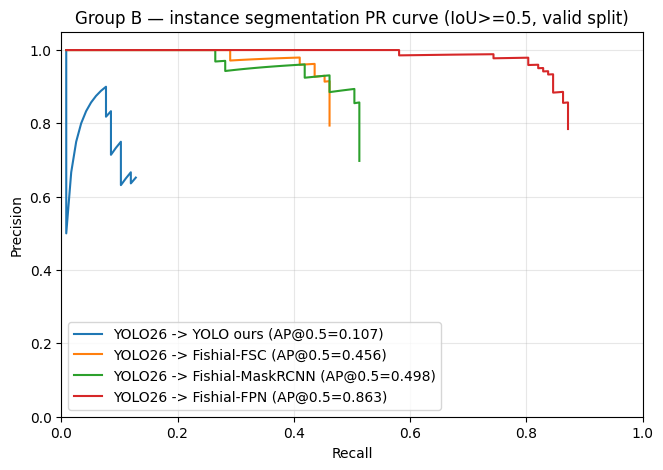

In [24]:
if HAS_FY:
    # Group B uses YOLO26's REAL per-detection confidence (no proxy needed) —
    # every pipeline shares the same detector front-end, and YOLO26 exposes
    # `result.boxes.conf`. So this is real mAP, not directional.
    yolo26_aps = {prefix: [compute_ap(b_per_image[prefix], b_gts_per_image, t) for t in iou_thresholds]
                  for prefix, _, _ in B_PIPELINES}

    cols = {}
    for prefix, label, _ in B_PIPELINES:
        cols[label] = {
            "AP@0.5": yolo26_aps[prefix][0],
            "AP@0.75": yolo26_aps[prefix][5],
            "mAP@[.5:.95]": float(np.mean(yolo26_aps[prefix])),
        }
    print("Group B — COCO-style AP on valid split (real YOLO26 confidence).")
    display(pd.DataFrame(cols).round(4))

    per_iou_rows = {}
    for i, t in enumerate(iou_thresholds):
        per_iou_rows[f"IoU>={t:.2f}"] = {label: yolo26_aps[prefix][i] for prefix, label, _ in B_PIPELINES}
    display(pd.DataFrame(per_iou_rows).T.round(4))

    fig, ax = plt.subplots(figsize=(7.5, 5))
    for prefix, label, _ in B_PIPELINES:
        r, p = pr_curve(b_per_image[prefix], b_gts_per_image, 0.5)
        ax.plot(r, p, label=f"{label} (AP@0.5={yolo26_aps[prefix][0]:.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.set_title("Group B — instance segmentation PR curve (IoU>=0.5, valid split)")
    ax.grid(alpha=0.3); ax.legend()
    plt.show()